# HH-PC SNN on SHD (Spiking Heidelberg Digits, 20 classes)

Audio, not vision: 700 cochlea channels, spoken digits 0-9 in English + German.
8332 train / 2088 test. HDF5 with `spikes/times`, `spikes/units`, `labels`,
`extra/speaker`.

**Reports:** Accuracy, Macro-F1, macro one-vs-rest ROC + AUC, per-epoch loss
(PC energy), per-epoch accuracy (train-subset vs validation).





In [1]:
# ── Cell 1: imports + config ──────────────────────────────────────────────
import os, glob, gzip, shutil, time, json, urllib.request
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Subset
import matplotlib.pyplot as plt

import sys
_hits = glob.glob('/kaggle/input/**/hhpc_base.py', recursive=True) + \
        glob.glob('/kaggle/working/**/hhpc_base.py', recursive=True) + \
        glob.glob('./hhpc_base.py')
assert _hits, 'hhpc_base.py not found — attach the dataset'
sys.path.insert(0, os.path.dirname(os.path.abspath(_hits[0])))
print('hhpc_base at:', _hits[0])
from hhpc_base import (PCSNNet, MetricAccumulator, EarlyStopper,
                       one_hot, set_seed, default_device, spike_rate_epoch)

# ---------------- CONFIG ----------------
DATA_DIR    = '/kaggle/working/shd'
N_CH        = 700         # SHD cochlea channels
POOL        = 5           # sum-pool channels: 700 -> 140
TBINS       = 50          # time bins over the clip
T_MAX       = 1.0         # seconds; SHD clips are ~0.6-1.4 s
NUM_CLASSES = 20

HIDDEN      = 400
DT          = 0.03
TAU_REF     = 0.15
I_BIAS = [1.5, 3.0] # [hidden, output]
STEPS_SPK   = 50
T_TRAIN     = 100
T_EVAL      = 50
ETA_X       = 0.05
LR          = 2e-4
WD          = 1e-5
EPOCHS      = 40
BATCH       = 128
PATIENCE    = 6
N_VAL_SPK   = 2           # speakers held out for validation
SEED        = 42
TRAIN_PROBE = 2000

D_IN = TBINS * (N_CH // POOL)
DEVICE = default_device()
set_seed(SEED)
os.makedirs(DATA_DIR, exist_ok=True)
print('device:', DEVICE, '| D_in:', D_IN, '| classes:', NUM_CLASSES)

hhpc_base at: /kaggle/input/datasets/ishraqkamaladib/hhpc-base/hhpc_base.py
device: cuda | D_in: 7000 | classes: 20


## 1. Get the data

Two paths: attach an SHD Kaggle dataset, or let the notebook download from
zenkelab.org (needs Internet **on** in the notebook settings).

In [2]:
# ── Cell 2: locate or download shd_train.h5 / shd_test.h5 ─────────────────
try:
    import h5py
except ImportError:
    os.system('pip install -q h5py'); import h5py

URLS = {'train': 'https://zenkelab.org/datasets/shd_train.h5.gz',
        'test':  'https://zenkelab.org/datasets/shd_test.h5.gz'}

def get_h5(split):
    # 1) already attached / already fetched?
    for pat in (f'/kaggle/input/**/shd_{split}.h5', f'{DATA_DIR}/shd_{split}.h5',
                f'/kaggle/input/**/shd_{split}.h5.gz'):
        hits = glob.glob(pat, recursive=True)
        if hits:
            p = hits[0]
            if p.endswith('.gz'):
                out = f'{DATA_DIR}/shd_{split}.h5'
                if not os.path.exists(out):
                    with gzip.open(p, 'rb') as fi, open(out, 'wb') as fo:
                        shutil.copyfileobj(fi, fo)
                return out
            return p
    # 2) download
    gz  = f'{DATA_DIR}/shd_{split}.h5.gz'
    out = f'{DATA_DIR}/shd_{split}.h5'
    print(f'downloading {split} ...', flush=True)
    urllib.request.urlretrieve(URLS[split], gz)
    with gzip.open(gz, 'rb') as fi, open(out, 'wb') as fo:
        shutil.copyfileobj(fi, fo)
    return out

H5_TRAIN, H5_TEST = get_h5('train'), get_h5('test')
with h5py.File(H5_TRAIN, 'r') as f:
    print('keys:', list(f.keys()))
    print('n train:', len(f['labels']))
    print('extra:', list(f['extra'].keys()) if 'extra' in f else 'none')

downloading train ...
downloading test ...
keys: ['extra', 'labels', 'spikes']
n train: 8156
extra: ['keys', 'meta_info', 'speaker']


## 2. Spikes -> fixed binned vectors

In [3]:
# ── Cell 3: bin (times, units) into a TBINS x (N_CH/POOL) frame ───────────
def load_shd(path, tbins=TBINS, pool=POOL, n_ch=N_CH, t_max=T_MAX):
    """Returns X (N, tbins*n_ch/pool) float32 in [0,1], y (N,), spk (N,).
    Spike counts per (time-bin, pooled-channel), log-compressed, scaled per
    sample. Channel sum-pooling by `pool` follows standard SHD practice."""
    ch = n_ch // pool
    with h5py.File(path, 'r') as f:
        times  = f['spikes']['times']
        units  = f['spikes']['units']
        labels = np.asarray(f['labels'], np.int64)
        spk = (np.asarray(f['extra']['speaker'], np.int64)
               if 'extra' in f and 'speaker' in f['extra']
               else np.zeros(len(labels), np.int64))

        X = np.zeros((len(labels), tbins * ch), np.float32)
        for i in range(len(labels)):
            t = np.asarray(times[i], np.float64)
            u = np.asarray(units[i], np.int64)
            if t.size == 0:
                continue
            ti = np.clip((t / t_max * tbins).astype(np.int64), 0, tbins - 1)
            ui = np.clip(u // pool, 0, ch - 1)
            cnt = np.bincount(ti * ch + ui, minlength=tbins * ch).astype(np.float32)
            cnt = np.log1p(cnt)
            m = cnt.max()
            X[i] = cnt / m if m > 0 else cnt
    return X, labels, spk


t0 = time.time()
Xtr_all, ytr_all, spk_tr = load_shd(H5_TRAIN)
Xte,     yte,     spk_te = load_shd(H5_TEST)
print(f'loaded in {time.time()-t0:.1f}s')
print('train', Xtr_all.shape, 'test', Xte.shape)
print('train speakers:', np.unique(spk_tr), '| test speakers:', np.unique(spk_te))
print('class counts (train):', np.bincount(ytr_all, minlength=NUM_CLASSES))

loaded in 5.9s
train (8156, 7000) test (2264, 7000)
train speakers: [ 0  1  2  3  6  7  8  9 10 11] | test speakers: [ 0  1  2  3  4  5  6  7  8  9 10 11]
class counts (train): [406 401 404 407 393 399 400 400 395 406 411 412 412 413 418 421 415 412
 410 421]


In [4]:
# ── Cell 4: SPEAKER-level train/val split + loaders ───────────────────────
# SHD's official test set holds out 2 speakers entirely. A random split would
# leak speakers into validation and inflate it (same failure as file-level
# splits on DVS128).
rng = np.random.RandomState(SEED)
spk_ids = np.unique(spk_tr)
val_spk = rng.choice(spk_ids, size=min(N_VAL_SPK, len(spk_ids)), replace=False)
val_mask = np.isin(spk_tr, val_spk)
tr_idx = np.where(~val_mask)[0]
val_idx = np.where(val_mask)[0]
print('held-out val speakers:', val_spk, '| val n =', len(val_idx))

def to_ds(X, y, idx=None):
    if idx is not None: X, y = X[idx], y[idx]
    return TensorDataset(torch.from_numpy(X), torch.from_numpy(y))

train_ds = to_ds(Xtr_all, ytr_all, tr_idx)
val_ds   = to_ds(Xtr_all, ytr_all, val_idx)
test_ds  = to_ds(Xte, yte)

kw = dict(num_workers=0, pin_memory=DEVICE.startswith('cuda'))
train_loader = DataLoader(train_ds, BATCH, shuffle=True,  **kw)
val_loader   = DataLoader(val_ds,   BATCH, shuffle=False, **kw)
test_loader  = DataLoader(test_ds,  BATCH, shuffle=False, **kw)

g = torch.Generator().manual_seed(SEED)
probe_idx = torch.randperm(len(train_ds), generator=g)[:TRAIN_PROBE].tolist()
probe_loader = DataLoader(Subset(train_ds, probe_idx), BATCH, shuffle=False, **kw)
print(len(train_ds), len(val_ds), len(test_ds), '| probe', len(probe_idx))

held-out val speakers: [10  1] | val n = 1692
6464 1692 2264 | probe 2000


## 3. Baselines first — do not skip

In [5]:
# ── Cell 5: logistic regression + backprop MLP ceiling ────────────────────
from sklearn.linear_model import LogisticRegression

lg = LogisticRegression(max_iter=2000, n_jobs=-1)
lg.fit(Xtr_all[tr_idx], ytr_all[tr_idx])
print(f'logreg      test acc {lg.score(Xte, yte)*100:.2f}%')

def quick_mlp(Xtr, ytr, Xte_, yte_, hidden=HIDDEN, epochs=25):
    m = nn.Sequential(nn.Linear(Xtr.shape[1], hidden), nn.ReLU(),
                      nn.Linear(hidden, NUM_CLASSES)).to(DEVICE)
    o = torch.optim.Adam(m.parameters(), lr=1e-3, weight_decay=WD)
    dl = DataLoader(TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr)),
                    BATCH, shuffle=True)
    Xt = torch.from_numpy(Xte_).to(DEVICE); yt = torch.from_numpy(yte_)
    best = 0.
    for _ in range(epochs):
        m.train()
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            o.zero_grad(); F.cross_entropy(m(xb), yb).backward(); o.step()
        m.eval()
        with torch.no_grad():
            best = max(best, (m(Xt).argmax(1).cpu() == yt).float().mean().item())
    return best

MLP_CEILING = quick_mlp(Xtr_all[tr_idx], ytr_all[tr_idx], Xte, yte)
print(f'bp-MLP      test acc {MLP_CEILING*100:.2f}%   <-- ceiling for this representation')

logreg      test acc 74.34%
bp-MLP      test acc 83.48%   <-- ceiling for this representation


## 4. Model

In [6]:
# ── Cell 6: build PCSNNet + refractory fix + per-layer I_bias ─────────────
import types

model = PCSNNet(layer_sizes=[D_IN, HIDDEN, NUM_CLASSES],
                dt=DT, device=DEVICE, lr=LR, weight_decay=WD,
                pc_activation='relu', input_encoding='poisson').to(DEVICE)

for c in model.cells:
    c.refr_steps = max(1, int(round(TAU_REF / DT)))

def forward_proxies(self, x_in, steps_spk):
    x0 = x_in.to(self.device).clamp(0, 1); B = x0.size(0)
    for cell in self.cells:
        cell.reset_states(B)
    p = (x0 * self.poisson_scale).clamp(0, 1)
    spk_train = (torch.rand(B, x0.size(1), steps_spk, device=self.device)
                 < p.unsqueeze(-1)).float()
    spike_sums = [torch.zeros(B, self.sizes[i+1], device=self.device)
                  for i in range(self.S)]
    for t in range(steps_spk):
        r = spk_train[:, :, t]
        for i in range(self.S):
            h = F.linear(r, self.syn[i].weight, self.syn[i].bias)
            I = h * self.current_gain + self.I_bias_list[i]
            spk, _ = self.cells[i](I)
            spike_sums[i] += spk
            r = spk
    self._last_spike_sums = spike_sums
    return [x0] + [(ss / float(steps_spk)).clamp(0, 1) for ss in spike_sums]

model.I_bias_list = I_BIAS
model.forward_proxies = types.MethodType(forward_proxies, model)


# ── soft PC targets ───────────────────────────────────────────────────────
# Hard one-hot gives each output unit (C-1) pushes toward silence for every 1
# push toward firing. Once f(z_c) hits 0 for all inputs, fprime(z_c)=0, the
# gradient vanishes and the weight row is frozen -> permanently dead unit.
# Ratio is 1:1 at C=2, 19:1 at C=20, 100:1 at C=101.
SOFT_TARGETS = True
TGT_HI, TGT_LO = 0.9, 0.1

def soft_one_hot(y, C, hi=TGT_HI, lo=TGT_LO):
    t = torch.full((y.size(0), C), lo / C, device=y.device)
    t.scatter_(1, y.view(-1, 1).long(), hi)
    return t

def make_target(y, C):
    return soft_one_hot(y, C) if SOFT_TARGETS else one_hot(y, C)

print('refr steps:', [c.refr_steps for c in model.cells],
      '| I_bias:', model.I_bias_list, '| steps_spk:', STEPS_SPK)
print(f'targets: {"soft" if SOFT_TARGETS else "hard one-hot"}'
      f'{f" (hi={TGT_HI}, lo/C={TGT_LO/NUM_CLASSES:.4f})" if SOFT_TARGETS else ""}')

refr steps: [5, 5] | I_bias: [1.5, 3.0] | steps_spk: 50
targets: soft (hi=0.9, lo/C=0.0050)


In [7]:
# ── Cell 7: proxy health ──────────────────────────────────────────────────
@torch.no_grad()
def proxy_health(model, loader):
    model.eval()
    for x, y in loader:
        p = model.forward_proxies(x.to(DEVICE).view(x.size(0), -1), STEPS_SPK)
        for i, pr in enumerate(p[1:], 1):
            print(f'  L{i}: mean {pr.mean():.4f}  frac>0 {(pr>0).float().mean():.4f}  '
                  f'std/sample {pr.std(0).mean():.4f}')
        out = p[-1]
        print(f'  output rate: mean {out.mean():.4f}  '
              f'per-class spread {out.mean(0).max()-out.mean(0).min():.4f}  '
              f'quantisation step {1/STEPS_SPK:.4f}')
        break

print('--- proxy health at init ---')
proxy_health(model, test_loader)

--- proxy health at init ---
  L1: mean 0.0667  frac>0 0.5990  std/sample 0.0453
  L2: mean 0.0946  frac>0 0.9047  std/sample 0.0221
  output rate: mean 0.0946  per-class spread 0.1503  quantisation step 0.0200


## 5. Evaluation + training loop

In [8]:
# ── Cell 8: evaluator (acc / macro-F1 / PC energy / per-class scores) ─────
@torch.no_grad()
def evaluate(model, loader, T_infer=T_EVAL, eval_seed=1234, want_scores=False):
    model.eval()
    Cn = model.sizes[-1]
    acc_pc, acc_ff = MetricAccumulator(Cn), MetricAccumulator(Cn)
    tot_e, tot_n = 0.0, 0
    scores, labels = [], []

    with torch.random.fork_rng():
        torch.manual_seed(eval_seed)
        for x, y in loader:
            x = x.to(DEVICE).view(x.size(0), -1); y = y.to(DEVICE)
            B = x.size(0)
            proxies = model.forward_proxies(x, STEPS_SPK)
            acc_ff.update(proxies[-1].argmax(1).cpu(), y.cpu())

            xs, _, _, _ = model.pc_infer(proxies, None, T_infer, ETA_X, False)
            out = xs[-1]
            acc_pc.update(out.argmax(1).cpu(), y.cpu())
            if want_scores:
                scores.append(out.cpu().numpy()); labels.append(y.cpu().numpy())

            _, _, _, e = model.pc_infer(proxies, one_hot(y, Cn), T_infer, ETA_X, True)
            tot_e += e * B; tot_n += B

    m_pc, m_ff = acc_pc.compute(), acc_ff.compute()
    r = {'acc': m_pc['acc'], 'f1': m_pc['f1'],
         'precision': m_pc['precision'], 'recall': m_pc['recall'],
         'ff_acc': m_ff['acc'], 'loss': tot_e / max(tot_n, 1)}
    if want_scores:
        r['scores'] = np.concatenate(scores); r['labels'] = np.concatenate(labels)
    return r


def roc_ovr(scores, labels, n_classes=NUM_CLASSES):
    """Per-class one-vs-rest ROC + macro-average curve (pure numpy)."""
    grid = np.linspace(0, 1, 201)
    tprs, aucs = [], []
    for c in range(n_classes):
        s = scores[:, c]; l = (labels == c).astype(int)
        o = np.argsort(-s); l = l[o]
        P, N = max(l.sum(), 1), max((1 - l).sum(), 1)
        tpr = np.concatenate([[0.], np.cumsum(l) / P, [1.]])
        fpr = np.concatenate([[0.], np.cumsum(1 - l) / N, [1.]])
        aucs.append(float(np.trapezoid(tpr, fpr)))
        tprs.append(np.interp(grid, fpr, tpr))
    return grid, np.mean(tprs, 0), float(np.mean(aucs)), aucs

In [9]:
# ── Cell 9: training loop with per-epoch history ──────────────────────────
CKPT = '/kaggle/working/hhpc_shd.pt'
hist = {'epoch': [], 'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [], 'val_f1': []}
stopper = EarlyStopper(patience=PATIENCE)
t0 = time.time()

for ep in range(1, EPOCHS + 1):
    model.train()
    for x, y in train_loader:
        x = x.to(DEVICE).view(x.size(0), -1); y = y.to(DEVICE)
        model.train_step(x, make_target(y, NUM_CLASSES),      # <-- soft targets
                         STEPS_SPK, T_TRAIN, ETA_X)

    tr = evaluate(model, probe_loader)
    va = evaluate(model, val_loader)
    for k, v in [('epoch', ep), ('train_loss', tr['loss']), ('val_loss', va['loss']),
                 ('train_acc', tr['acc']), ('val_acc', va['acc']), ('val_f1', va['f1'])]:
        hist[k].append(v)

    stop, improved = stopper.step(va['f1'], ep)
    if improved:
        torch.save(model.state_dict(), CKPT)
    print(f"ep {ep:02d} | train_loss {tr['loss']:.5f} val_loss {va['loss']:.5f} "
          f"| train_acc {tr['acc']*100:5.2f} val_acc {va['acc']*100:5.2f} "
          f"val_F1 {va['f1']*100:5.2f}{'  *' if improved else ''}", flush=True)
    if stop:
        print(f'early stop @ {ep} (best epoch {stopper.best_epoch})'); break

model.load_state_dict(torch.load(CKPT, map_location=DEVICE))
print(f'train time {time.time()-t0:.1f}s | best val macro-F1 {stopper.best*100:.2f}%')

/usr/lib/python3.12/contextlib.py:137: UserWarning: CUDA reports that you have 2 available devices, and you have used fork_rng without explicitly specifying which devices are being used. For safety, we initialize *every* CUDA device by default, which can be quite slow if you have a lot of CUDAs. If you know that you are only making use of a few CUDA devices, set the environment variable CUDA_VISIBLE_DEVICES or the 'devices' keyword argument of fork_rng with the set of devices you are actually using. For example, if you are using CPU only, set device.upper()_VISIBLE_DEVICES= or devices=[]; if you are using device 0 only, set CUDA_VISIBLE_DEVICES=0 or devices=[0].  To initialize all devices and suppress this warning, set the 'devices' keyword argument to `range(torch.cuda.device_count())`.
  return next(self.gen)


ep 01 | train_loss 0.00798 val_loss 0.00957 | train_acc 71.95 val_acc 58.10 val_F1 54.41  *
ep 02 | train_loss 0.00514 val_loss 0.00747 | train_acc 85.55 val_acc 67.26 val_F1 66.26  *
ep 03 | train_loss 0.00388 val_loss 0.00650 | train_acc 90.40 val_acc 69.98 val_F1 69.10  *
ep 04 | train_loss 0.00319 val_loss 0.00609 | train_acc 91.95 val_acc 71.57 val_F1 69.67  *
ep 05 | train_loss 0.00172 val_loss 0.00495 | train_acc 96.80 val_acc 73.88 val_F1 72.80  *
ep 06 | train_loss 0.00126 val_loss 0.00472 | train_acc 97.55 val_acc 73.11 val_F1 72.11
ep 07 | train_loss 0.00092 val_loss 0.00435 | train_acc 99.10 val_acc 75.35 val_F1 75.23  *
ep 08 | train_loss 0.00074 val_loss 0.00418 | train_acc 99.40 val_acc 73.64 val_F1 73.50
ep 09 | train_loss 0.00062 val_loss 0.00404 | train_acc 99.50 val_acc 74.82 val_F1 74.01
ep 10 | train_loss 0.00052 val_loss 0.00382 | train_acc 99.50 val_acc 75.35 val_F1 74.41
ep 11 | train_loss 0.00048 val_loss 0.00376 | train_acc 99.50 val_acc 76.36 val_F1 75.27  *


## 6. Curves

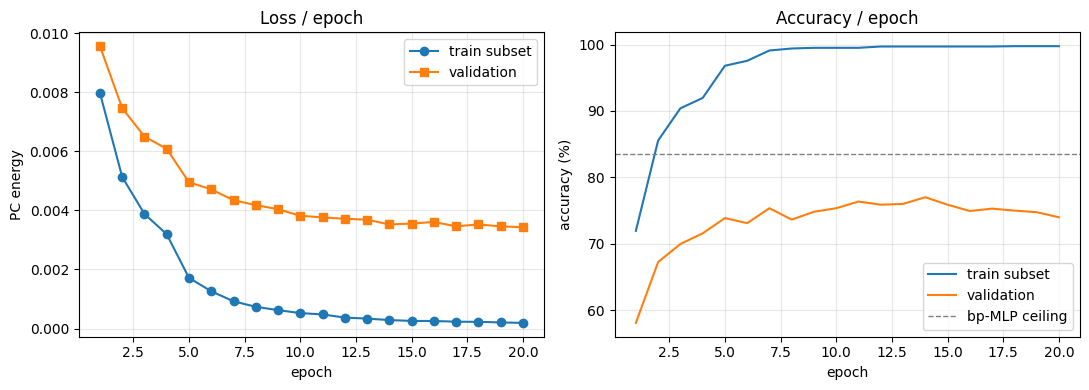

In [10]:
# ── Cell 10: loss + accuracy curves ───────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hist['epoch'], hist['train_loss'], 'o-', label='train subset')
ax[0].plot(hist['epoch'], hist['val_loss'],   's-', label='validation')
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('PC energy'); ax[0].set_title('Loss / epoch')
ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(hist['epoch'], np.array(hist['train_acc'])*100,  label='train subset')
ax[1].plot(hist['epoch'], np.array(hist['val_acc'])*100,   label='validation')
ax[1].axhline(MLP_CEILING*100, ls='--', c='gray', lw=1, label='bp-MLP ceiling')
ax[1].set_xlabel('epoch'); ax[1].set_ylabel('accuracy (%)'); ax[1].set_title('Accuracy / epoch')
ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig('/kaggle/working/shd_curves.png', dpi=150); plt.show()

## 7. Test metrics

SHD test      accuracy : 80.83%
              macro F1 : 79.56%
              precision: 81.23%   recall: 80.46%
     macro OvR ROC-AUC : 0.9729


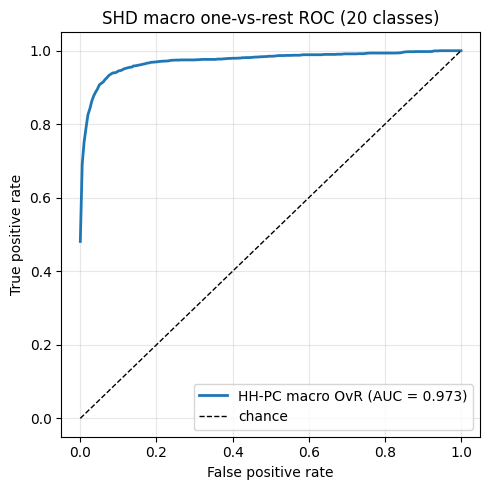


worst 3 classes by AUC: [19, 2, 15]

--- proxy health after training (C=20) ---
  L1: mean 0.0551  frac>0 0.4478  std/sample 0.0512
  L2: mean 0.0249  frac>0 0.2668  std/sample 0.0488
  output rate: mean 0.0249  per-class spread 0.0341  quantisation step 0.0200


In [18]:
# ── Cell 11: accuracy, macro-F1, macro OvR ROC-AUC, scaling probe ─────────
te = evaluate(model, test_loader, want_scores=True)
grid, mtpr, macro_auc, per_class_auc = roc_ovr(te['scores'], te['labels'])

print(f"SHD test      accuracy : {te['acc']*100:.2f}%")
print(f"              macro F1 : {te['f1']*100:.2f}%")
print(f"              precision: {te['precision']*100:.2f}%   recall: {te['recall']*100:.2f}%")
print(f"     macro OvR ROC-AUC : {macro_auc:.4f}")


plt.figure(figsize=(5, 5))
plt.plot(grid, mtpr, lw=2, label=f'HH-PC macro OvR (AUC = {macro_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='chance')
plt.xlabel('False positive rate'); plt.ylabel('True positive rate')
plt.title('SHD macro one-vs-rest ROC (20 classes)')
plt.legend(loc='lower right'); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig('/kaggle/working/shd_roc.png', dpi=150); plt.show()

print('\nworst 3 classes by AUC:',
      sorted(range(NUM_CLASSES), key=lambda c: per_class_auc[c])[:3])

# --- output-layer scaling probe (for the C-sweep study) ---
print('\n--- proxy health after training (C=20) ---')
proxy_health(model, test_loader)

In [12]:
# ── Cell A: score collection (PC readout + FF rate readout) ───────────────
@torch.no_grad()
def collect_scores(model, loader, T_infer=T_EVAL, eval_seed=1234):
    """One pass returning settled-PC scores, feed-forward rate scores, labels."""
    model.eval()
    pc, ff, ys = [], [], []
    with torch.random.fork_rng():
        torch.manual_seed(eval_seed)
        for x, y in loader:
            x = x.to(DEVICE).view(x.size(0), -1)
            proxies = model.forward_proxies(x, STEPS_SPK)
            xs, _, _, _ = model.pc_infer(proxies, None, T_infer, ETA_X, False)
            pc.append(xs[-1].cpu().numpy())
            ff.append(proxies[-1].cpu().numpy())
            ys.append(y.numpy())
    return np.concatenate(pc), np.concatenate(ff), np.concatenate(ys)

S_PC, S_FF, y_true = collect_scores(model, test_loader)
print('scores:', S_PC.shape, '| labels:', y_true.shape)

scores: (2264, 20) | labels: (2264,)


In [13]:
# ── Cell B: accuracy + macro/weighted F1, both readouts ───────────────────
from sklearn.metrics import (accuracy_score, f1_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix)

y_pc, y_ff = S_PC.argmax(1), S_FF.argmax(1)

def report(name, y_hat):
    acc = accuracy_score(y_true, y_hat)
    f1m = f1_score(y_true, y_hat, average='macro',    zero_division=0)
    f1w = f1_score(y_true, y_hat, average='weighted', zero_division=0)
    p, r, _, _ = precision_recall_fscore_support(y_true, y_hat, average='macro',
                                                 zero_division=0)
    print(f'{name:22s} acc {acc*100:6.2f}%  macroF1 {f1m*100:6.2f}%  '
          f'weightedF1 {f1w*100:6.2f}%  macroP {p*100:6.2f}%  macroR {r*100:6.2f}%')
    return dict(acc=acc, macro_f1=f1m, weighted_f1=f1w, macro_p=p, macro_r=r)

print('SHD test set, n =', len(y_true))
M_PC = report('PC readout', y_pc)
M_FF = report('FF rate readout', y_ff)
print(f'{"bp-MLP ceiling":22s} acc {MLP_CEILING*100:6.2f}%   '
      f'(PC reaches {M_PC["acc"]/MLP_CEILING*100:.1f}% of it)')

print('\nPer-class report (PC readout):')
print(classification_report(y_true, y_pc, digits=3, zero_division=0))

CM = confusion_matrix(y_true, y_pc)
rec_pc = CM.diagonal() / CM.sum(1).clip(1)
print('dead classes (recall == 0):', np.where(rec_pc == 0)[0].tolist())

SHD test set, n = 2264
PC readout             acc  80.83%  macroF1  79.56%  weightedF1  79.90%  macroP  81.23%  macroR  80.46%
FF rate readout        acc  69.48%  macroF1  68.49%  weightedF1  68.65%  macroP  73.10%  macroR  69.63%
bp-MLP ceiling         acc  83.48%   (PC reaches 96.8% of it)

Per-class report (PC readout):
              precision    recall  f1-score   support

           0      0.704     0.922     0.798       103
           1      0.716     0.676     0.695       108
           2      0.985     0.619     0.760       105
           3      0.797     0.578     0.670       102
           4      0.903     0.966     0.933       116
           5      0.794     0.736     0.764       110
           6      0.871     0.927     0.898       109
           7      0.959     0.853     0.903       109
           8      0.974     0.991     0.983       114
           9      0.550     0.854     0.669       103
          10      0.791     0.869     0.828       122
          11      0.983   

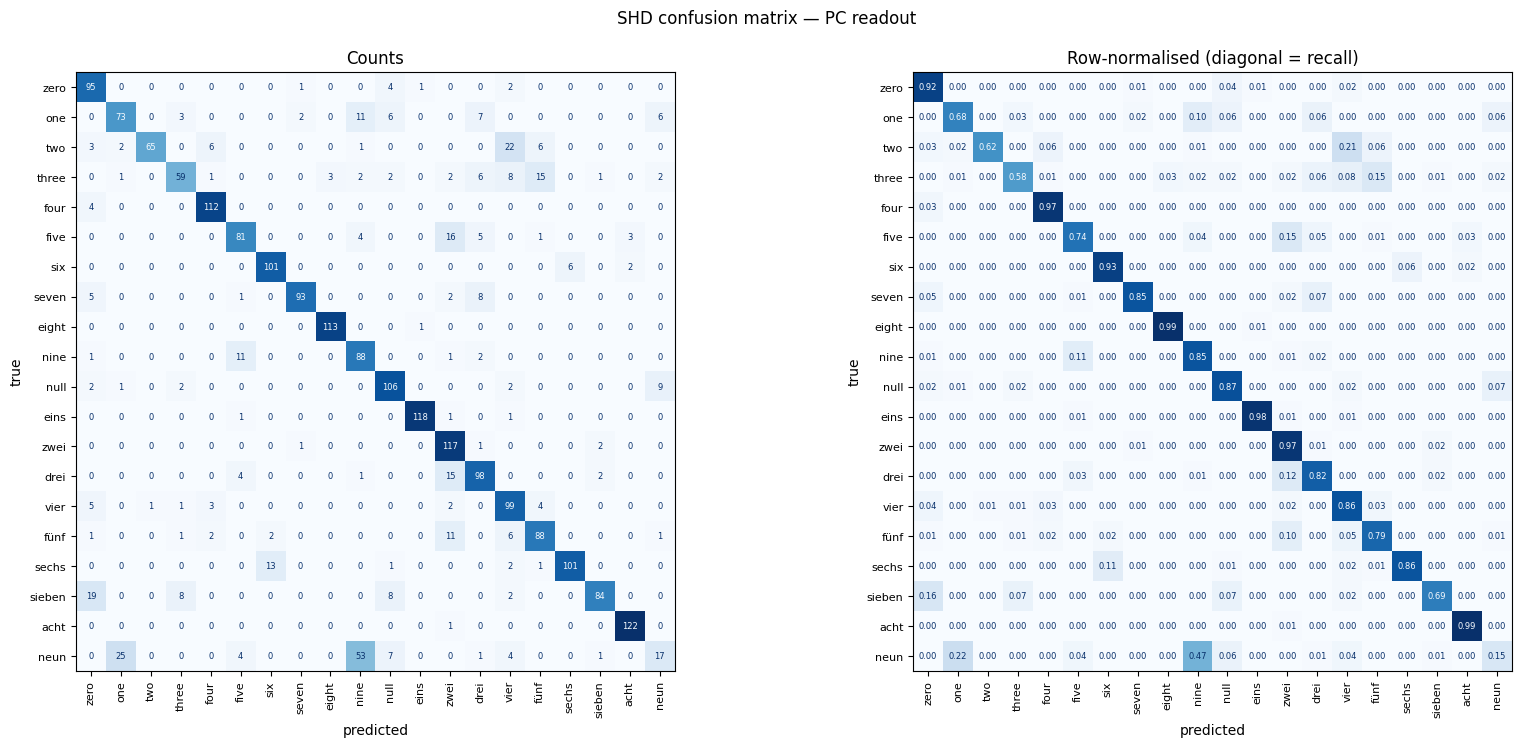

confusions above 5% of a true class:
  neun    (19) -> nine    ( 9)   47.3%  <-- same digit, other language
  neun    (19) -> one     ( 1)   22.3%
  two     ( 2) -> vier    (14)   21.0%
  sieben  (17) -> zero    ( 0)   15.7%
  three   ( 3) -> fünf    (15)   14.7%
  five    ( 5) -> zwei    (12)   14.5%
  drei    (13) -> zwei    (12)   12.5%
  sechs   (16) -> six     ( 6)   11.0%  <-- same digit, other language
  nine    ( 9) -> five    ( 5)   10.7%
  one     ( 1) -> nine    ( 9)   10.2%
  fünf    (15) -> zwei    (12)    9.8%
  three   ( 3) -> vier    (14)    7.8%

cross-language errors (same digit, wrong language): 88 of 434 total errors (20.3%)


In [19]:
# ── Cell G: confusion matrix ──────────────────────────────────────────────
from sklearn.metrics import ConfusionMatrixDisplay

# SHD label order: 0-9 English "zero".."nine", 10-19 German "null".."neun"
LABELS = ['zero','one','two','three','four','five','six','seven','eight','nine',
          'null','eins','zwei','drei','vier','fünf','sechs','sieben','acht','neun']

fig, ax = plt.subplots(1, 2, figsize=(17, 7.5))

ConfusionMatrixDisplay(CM, display_labels=LABELS).plot(
    ax=ax[0], cmap='Blues', colorbar=False, values_format='d')
ax[0].set_title('Counts')

CMn = CM / CM.sum(1, keepdims=True).clip(1)          # row-normalised = per-class recall
ConfusionMatrixDisplay(CMn, display_labels=LABELS).plot(
    ax=ax[1], cmap='Blues', colorbar=False, values_format='.2f')
ax[1].set_title('Row-normalised (diagonal = recall)')

for a in ax:
    a.set_xlabel('predicted'); a.set_ylabel('true')
    plt.setp(a.get_xticklabels(), rotation=90, fontsize=8)
    plt.setp(a.get_yticklabels(), fontsize=8)
    for t in a.texts:
        t.set_fontsize(6)
plt.suptitle('SHD confusion matrix — PC readout', y=0.99)
plt.tight_layout()
plt.savefig('/kaggle/working/shd_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# --- what's actually being confused -------------------------------------
off = CMn.copy(); np.fill_diagonal(off, 0)
pairs = [(int(i), int(j), off[i, j]) for i in range(NUM_CLASSES)
         for j in range(NUM_CLASSES) if off[i, j] > 0.05]
pairs.sort(key=lambda p: -p[2])
print('confusions above 5% of a true class:')
for i, j, v in pairs[:12]:
    tag = '  <-- same digit, other language' if abs(i - j) == 10 else ''
    print(f'  {LABELS[i]:7s} ({i:2d}) -> {LABELS[j]:7s} ({j:2d})  {v*100:5.1f}%{tag}')

cross = sum(CM[i, j] for i in range(NUM_CLASSES) for j in range(NUM_CLASSES)
            if abs(i - j) == 10)
errs = CM.sum() - np.trace(CM)
print(f'\ncross-language errors (same digit, wrong language): '
      f'{cross} of {errs} total errors ({cross/max(errs,1)*100:.1f}%)')

macro OvR AUC     0.9722   (curve 0.9722)
weighted OvR AUC  0.9728
micro AUC         0.9721   (curve 0.9721)
worst 3 by AUC: [(19, np.float64(0.8)), (2, np.float64(0.918)), (15, np.float64(0.934))]


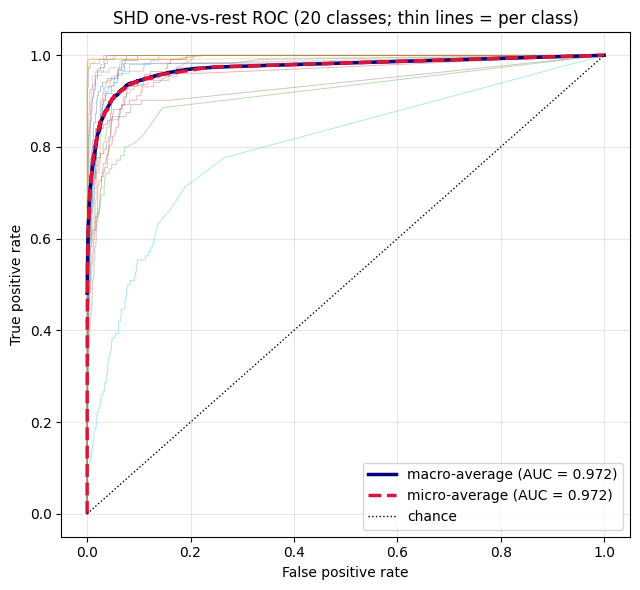

In [14]:
# ── Cell C: ROC-AUC, one-vs-rest + macro + micro ──────────────────────────
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize

classes = np.arange(NUM_CLASSES)
Y_bin = label_binarize(y_true, classes=classes)

fpr, tpr, roc_auc = {}, {}, {}
for c in classes:
    fpr[c], tpr[c], _ = roc_curve(Y_bin[:, c], S_PC[:, c])
    roc_auc[c] = auc(fpr[c], tpr[c])

fpr['micro'], tpr['micro'], _ = roc_curve(Y_bin.ravel(), S_PC.ravel())
roc_auc['micro'] = auc(fpr['micro'], tpr['micro'])

grid = np.unique(np.concatenate([fpr[c] for c in classes]))
mean_tpr = np.mean([np.interp(grid, fpr[c], tpr[c]) for c in classes], axis=0)
fpr['macro'], tpr['macro'] = grid, mean_tpr
roc_auc['macro'] = auc(grid, mean_tpr)

# NOTE: roc_auc_score(..., multi_class='ovr') demands rows summing to 1, which
# the settled PC output does not satisfy. Scoring against the binarised labels
# is the identical OvR average and needs no normalisation.
AUC_MACRO = roc_auc_score(Y_bin, S_PC, average='macro')
AUC_WTD   = roc_auc_score(Y_bin, S_PC, average='weighted')
AUC_MICRO = roc_auc_score(Y_bin, S_PC, average='micro')

print(f'macro OvR AUC     {AUC_MACRO:.4f}   (curve {roc_auc["macro"]:.4f})')
print(f'weighted OvR AUC  {AUC_WTD:.4f}')
print(f'micro AUC         {AUC_MICRO:.4f}   (curve {roc_auc["micro"]:.4f})')
order = np.argsort([roc_auc[c] for c in classes])
print('worst 3 by AUC:', [(int(c), round(roc_auc[c], 3)) for c in order[:3]])

plt.figure(figsize=(6.5, 6))
for c in classes:
    plt.plot(fpr[c], tpr[c], lw=0.7, alpha=0.35)
plt.plot(fpr['macro'], tpr['macro'], lw=2.5, color='navy',
         label=f'macro-average (AUC = {roc_auc["macro"]:.3f})')
plt.plot(fpr['micro'], tpr['micro'], lw=2.5, color='crimson', ls='--',
         label=f'micro-average (AUC = {roc_auc["micro"]:.3f})')
plt.plot([0, 1], [0, 1], 'k:', lw=1, label='chance')
plt.xlabel('False positive rate'); plt.ylabel('True positive rate')
plt.title(f'SHD one-vs-rest ROC ({NUM_CLASSES} classes; thin lines = per class)')
plt.legend(loc='lower right'); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig('/kaggle/working/shd_roc.png', dpi=150); plt.show()

In [15]:
# ── Cell D: instrument forward_proxies + measure spike counts ─────────────
# Re-patch to also record input spike count. Functionally identical to the
# version in Cell 6, so applying it after training changes nothing.
def forward_proxies_instr(self, x_in, steps_spk):
    x0 = x_in.to(self.device).clamp(0, 1); B = x0.size(0)
    for cell in self.cells:
        cell.reset_states(B)
    p = (x0 * self.poisson_scale).clamp(0, 1)
    spk_train = (torch.rand(B, x0.size(1), steps_spk, device=self.device)
                 < p.unsqueeze(-1)).float()
    self._input_spikes = float(spk_train.sum())
    spike_sums = [torch.zeros(B, self.sizes[i+1], device=self.device)
                  for i in range(self.S)]
    for t in range(steps_spk):
        r = spk_train[:, :, t]
        for i in range(self.S):
            h = F.linear(r, self.syn[i].weight, self.syn[i].bias)
            I = h * self.current_gain + self.I_bias_list[i]
            spk, _ = self.cells[i](I)
            spike_sums[i] += spk
            r = spk
    self._last_spike_sums = spike_sums
    return [x0] + [(ss / float(steps_spk)).clamp(0, 1) for ss in spike_sums]

model._input_spikes = 0.
model.forward_proxies = types.MethodType(forward_proxies_instr, model)

@torch.no_grad()
def measure_spikes(model, loader, eval_seed=1234):
    model.eval()
    n, in_spk = 0, 0.
    layer_spk = [0.] * model.S
    with torch.random.fork_rng():
        torch.manual_seed(eval_seed)
        for x, _ in loader:
            x = x.to(DEVICE).view(x.size(0), -1)
            model.forward_proxies(x, STEPS_SPK)
            in_spk += model._input_spikes
            for i, ss in enumerate(model.last_spike_sums()):
                layer_spk[i] += float(ss.sum())
            n += x.size(0)
    return {'n': n, 'input_per_sample': in_spk / n,
            'layer_per_sample': [s / n for s in layer_spk],
            'input_rate': in_spk / (n * D_IN * STEPS_SPK),
            'layer_rate': [layer_spk[i] / (n * model.sizes[i+1] * STEPS_SPK)
                           for i in range(model.S)]}

SPK = measure_spikes(model, test_loader)
print(f"input   {SPK['input_per_sample']:9.1f} spikes/sample (rate {SPK['input_rate']:.4f})")
for i, (s, r) in enumerate(zip(SPK['layer_per_sample'], SPK['layer_rate'])):
    print(f"layer {i+1} {s:9.1f} spikes/sample (rate {r:.4f})")
print(f"total   {SPK['input_per_sample'] + sum(SPK['layer_per_sample']):9.1f} spikes/sample")

input     39099.0 spikes/sample (rate 0.1117)
layer 1    1115.5 spikes/sample (rate 0.0558)
layer 2      24.7 spikes/sample (rate 0.0247)
total     40239.1 spikes/sample


In [16]:
# ── Cell E: SOP / FLOP accounting ─────────────────────────────────────────
SIZES = [D_IN, HIDDEN, NUM_CLASSES]

# SOPs: on event-driven hardware a synapse works only when its presynaptic
# neuron spikes, so layer i costs (spikes into i) x fan_out(i) accumulates.
pre_spikes = [SPK['input_per_sample']] + SPK['layer_per_sample'][:-1]
SOP_layer  = [pre_spikes[i] * SIZES[i+1] for i in range(len(pre_spikes))]
SOP_TOTAL  = sum(SOP_layer)

# HH membrane dynamics, per neuron per step. Transcendentals counted as 1 op,
# so this is a lower bound on real hardware.
HH_FLOP_BREAKDOWN = {
    'gate rate constants (alpha/beta x 3 gates)': 27,
    'gate integration (3 gates x 8)':             24,
    'I_Na  (m^3 . gNa . h . (V-ENa))':             6,
    'I_K   (n^4 . gK . (V-EK))':                   5,
    'I_leak':                                      2,
    'dV, Euler step, tanh squash':                 9,
    'threshold, reset, refractory update':         6,
}
FLOPS_PER_HH_STEP = sum(HH_FLOP_BREAKDOWN.values())
FLOP_HH = STEPS_SPK * (HIDDEN + NUM_CLASSES) * FLOPS_PER_HH_STEP

# PC settling: T iterations of forward projections + feedback (hidden only)
fwd_mac = sum(SIZES[i] * SIZES[i+1] for i in range(len(SIZES)-1))
fb_mac  = sum(SIZES[i+1] * SIZES[i+2] for i in range(len(SIZES)-2))
elem    = 6 * sum(SIZES[1:])
FLOP_PC = T_EVAL * (2*fwd_mac + 2*fb_mac + elem) + 2*fwd_mac

FLOP_ANN   = 2 * fwd_mac          # one dense MLP forward pass, same layer sizes
FLOP_TOTAL = FLOP_HH + FLOP_PC

print(f'{"":36s}{"per sample":>16s}')
print('-'*52)
print(f'{"SOPs, layer 1 (input->hidden)":36s}{SOP_layer[0]:16,.0f}')
print(f'{"SOPs, layer 2 (hidden->output)":36s}{SOP_layer[1]:16,.0f}')
print(f'{"SOPs, total":36s}{SOP_TOTAL:16,.0f}')
print()
print(f'{"FLOPs, HH membrane dynamics":36s}{FLOP_HH:16,.0f}')
print(f'{"FLOPs, PC settling (T=%d)" % T_EVAL:36s}{FLOP_PC:16,.0f}')
print(f'{"FLOPs, total":36s}{FLOP_TOTAL:16,.0f}')
print()
print(f'{"dense-ANN equivalent (1 fwd pass)":36s}{FLOP_ANN:16,.0f}')
print(f'{"HH-PC / ANN FLOP ratio":36s}{FLOP_TOTAL/FLOP_ANN:15.2f}x')
print()
print(f'PC settling = {FLOP_PC/FLOP_TOTAL*100:.1f}% of FLOPs; '
      f'HH dynamics = {FLOP_HH/FLOP_TOTAL*100:.1f}%')
print(f'dense-equivalent spiking MACs: {STEPS_SPK*fwd_mac:,.0f} -> '
      f'event-driven SOPs are {STEPS_SPK*fwd_mac/max(SOP_TOTAL,1):.1f}x fewer')
print(f'\nHH per-step constant = {FLOPS_PER_HH_STEP} FLOPs:')
for k, v in HH_FLOP_BREAKDOWN.items():
    print(f'   {k:44s} {v:3d}')

                                          per sample
----------------------------------------------------
SOPs, layer 1 (input->hidden)             15,639,588
SOPs, layer 2 (hidden->output)                22,309
SOPs, total                               15,661,897

FLOPs, HH membrane dynamics                1,659,000
FLOPs, PC settling (T=50)                287,342,000
FLOPs, total                             289,001,000

dense-ANN equivalent (1 fwd pass)          5,616,000
HH-PC / ANN FLOP ratio                        51.46x

PC settling = 99.4% of FLOPs; HH dynamics = 0.6%
dense-equivalent spiking MACs: 140,400,000 -> event-driven SOPs are 9.0x fewer

HH per-step constant = 79 FLOPs:
   gate rate constants (alpha/beta x 3 gates)    27
   gate integration (3 gates x 8)                24
   I_Na  (m^3 . gNa . h . (V-ENa))                6
   I_K   (n^4 . gK . (V-EK))                      5
   I_leak                                         2
   dV, Euler step, tanh squash               

In [17]:
# ── Cell F: persist results ───────────────────────────────────────────────
w = model.syn[1].weight.detach()
norms = np.array([float(w[c].norm()) for c in range(NUM_CLASSES)])

RES = {
  'dataset': 'SHD', 'n_test': int(len(y_true)),
  'config': {'D_in': D_IN, 'hidden': HIDDEN, 'tbins': TBINS, 'pool': POOL,
             'steps_spk': STEPS_SPK, 'T_train': T_TRAIN, 'T_eval': T_EVAL,
             'tau_ref': TAU_REF, 'I_bias': I_BIAS, 'lr': LR, 'wd': WD,
             'soft_targets': SOFT_TARGETS, 'seed': SEED,
             'val_speakers': val_spk.tolist()},
  'pc_readout': M_PC, 'ff_readout': M_FF, 'mlp_ceiling': MLP_CEILING,
  'auc': {'macro': float(AUC_MACRO), 'weighted': float(AUC_WTD),
          'micro': float(AUC_MICRO),
          'per_class': {int(c): float(roc_auc[c]) for c in classes}},
  'ops': {'sop_per_layer': SOP_layer, 'sop_total': SOP_TOTAL,
          'flop_hh': FLOP_HH, 'flop_pc': FLOP_PC, 'flop_total': FLOP_TOTAL,
          'flop_ann_equiv': FLOP_ANN, 'flop_ratio': FLOP_TOTAL/FLOP_ANN,
          'flops_per_hh_step': FLOPS_PER_HH_STEP,
          'hh_flop_breakdown': HH_FLOP_BREAKDOWN},
  'spikes': SPK, 'output_weight_norms': norms.tolist(),
  'dead_classes': np.where(rec_pc == 0)[0].tolist(),
  'confusion': CM.tolist(), 'history': hist,
}
with open('/kaggle/working/shd_full_results.json', 'w') as f:
    json.dump(RES, f, indent=2)

print(f"HEADLINE  acc {M_PC['acc']*100:.2f}  macroF1 {M_PC['macro_f1']*100:.2f}  "
      f"AUC {AUC_MACRO:.4f}  |  {SOP_TOTAL/1e6:.2f} MSOP  {FLOP_TOTAL/1e6:.2f} MFLOP"
      f"  |  {M_PC['acc']/MLP_CEILING*100:.1f}% of bp ceiling")
print('saved -> /kaggle/working/shd_full_results.json')

HEADLINE  acc 80.83  macroF1 79.56  AUC 0.9722  |  15.66 MSOP  289.00 MFLOP  |  96.8% of bp ceiling
saved -> /kaggle/working/shd_full_results.json
